In [ ]:
using CairoMakie, CSV, DataFrames, ForwardDiff, LaTeXStrings

true

In [2]:
output_dir = "../../assets/plots/plotting-basics"

"../../assets/plots/plotting-basics"

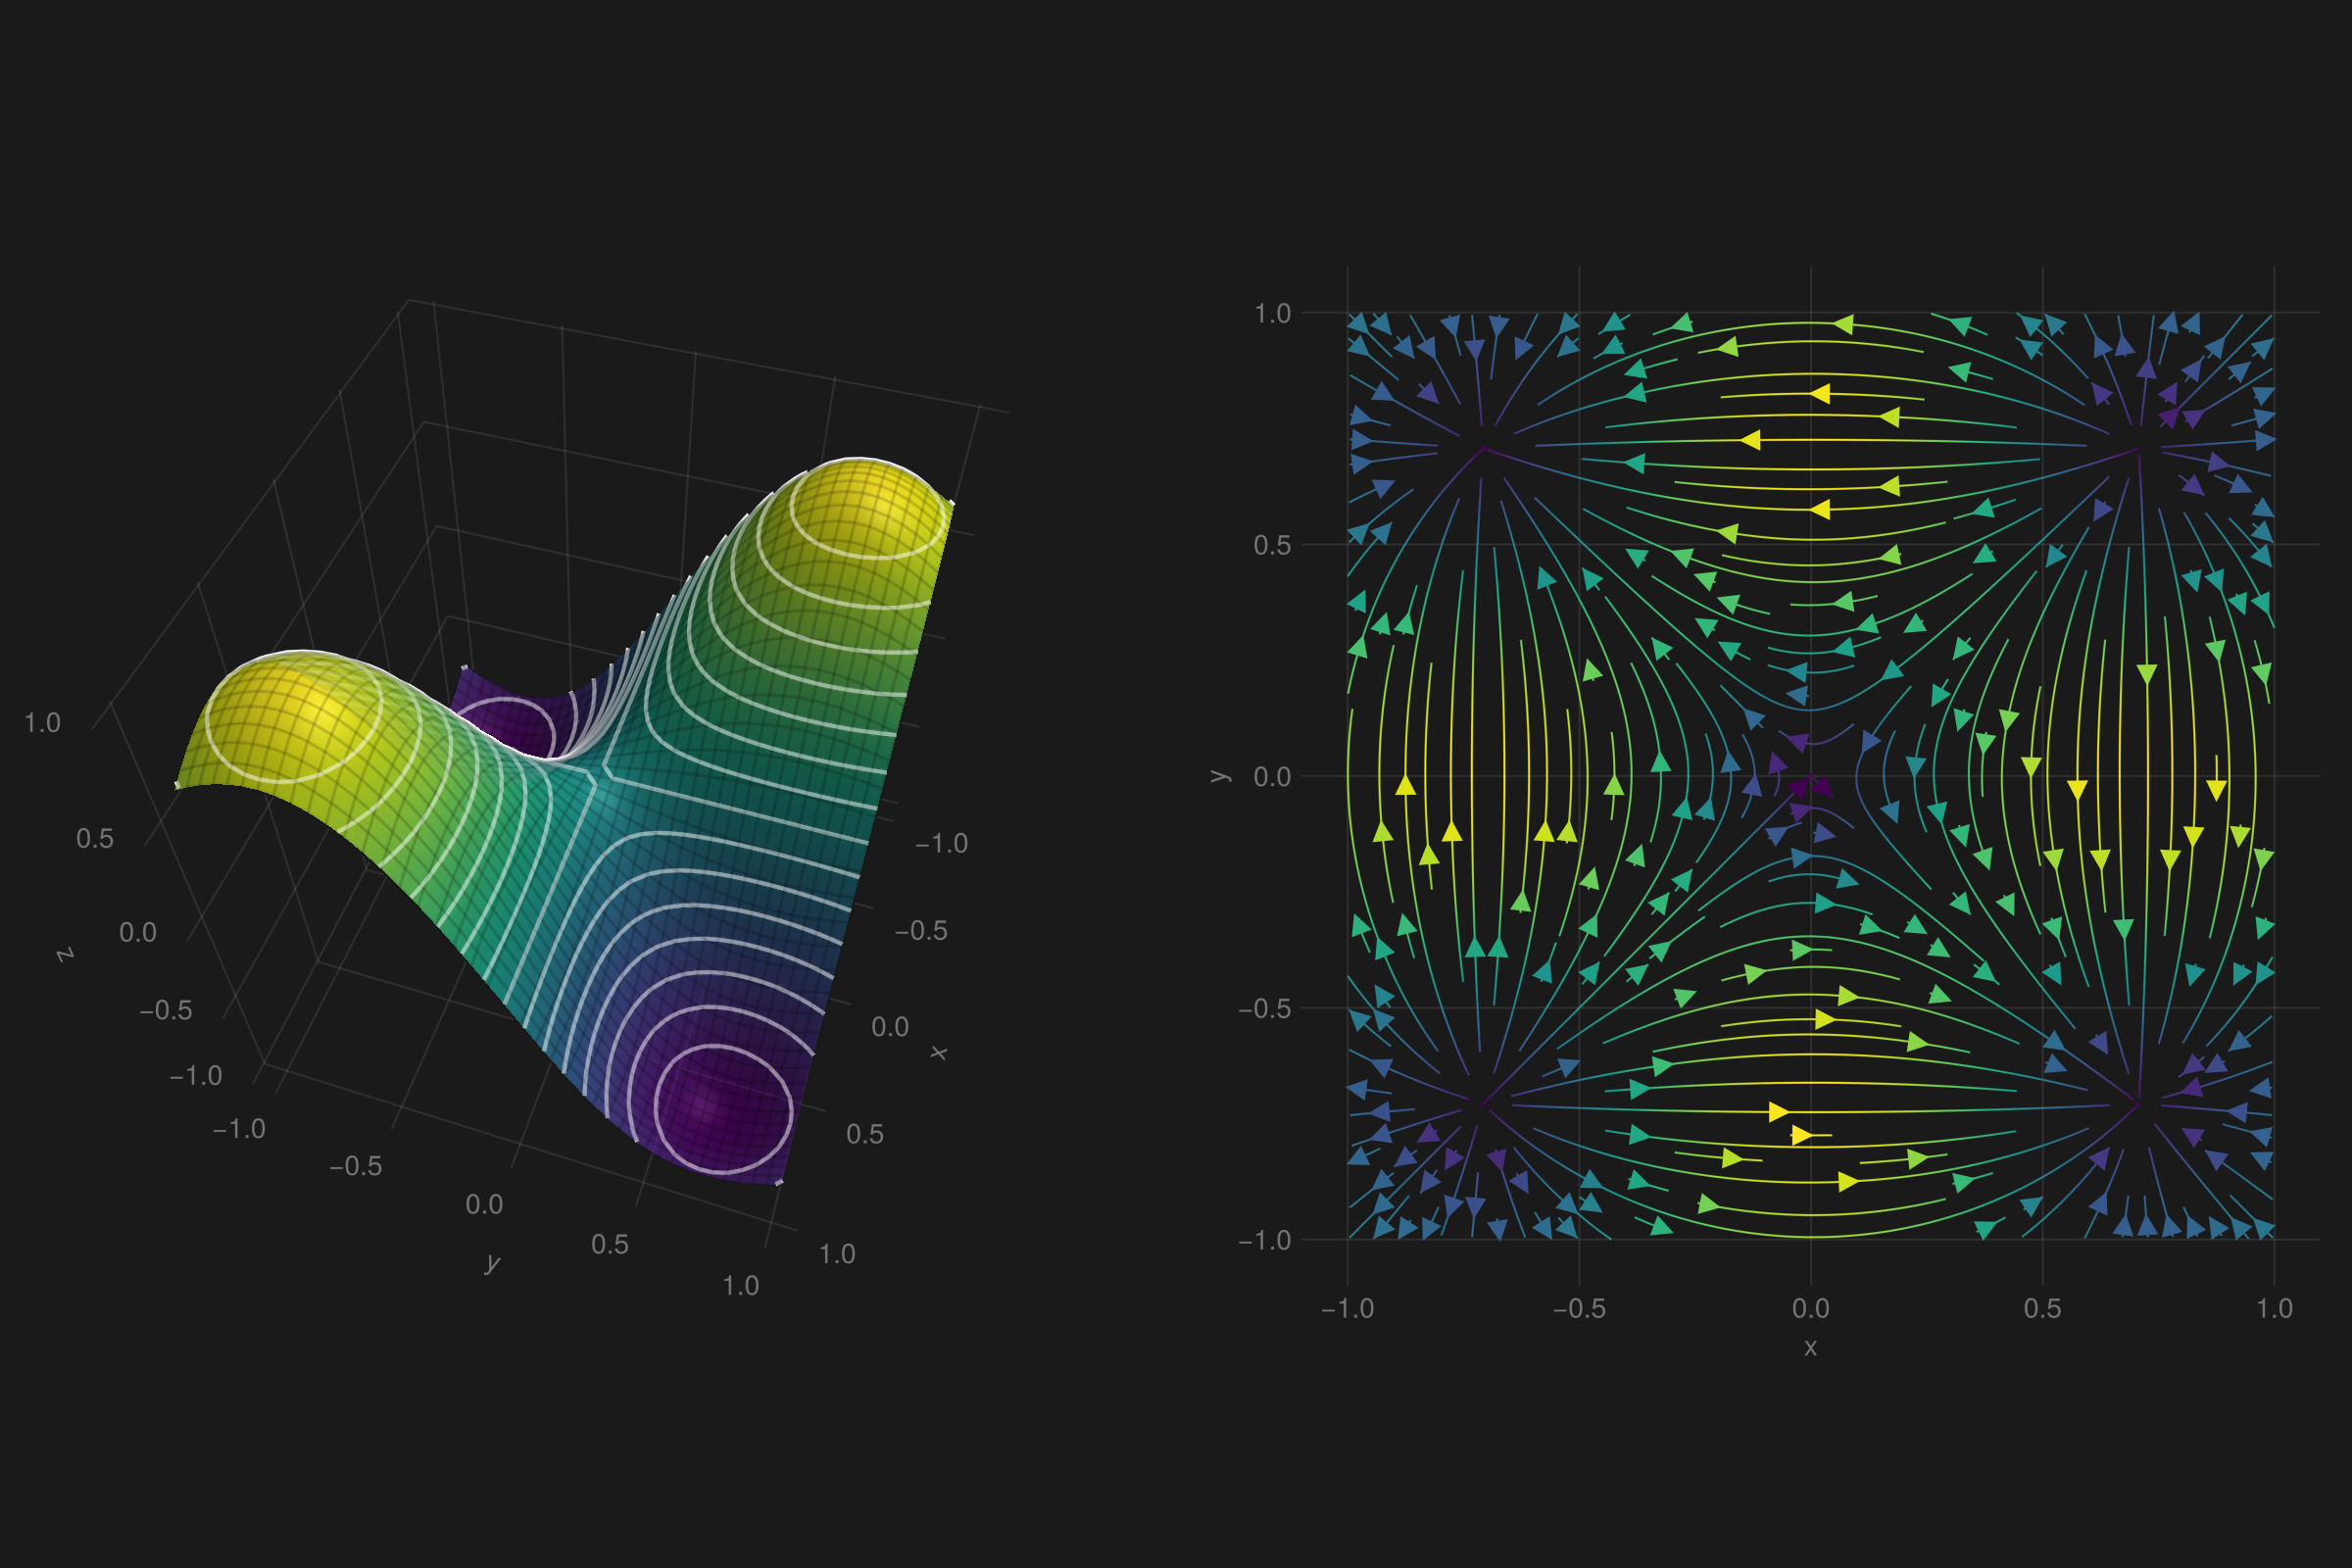

In [11]:
# example modified from  mthelm85
using GLMakie
GLMakie.activate!()

f(x, y) = -5 * x * y * exp(-x^2 - y^2)
x = y = -1:0.05:1.0
z = [f(i, j) for i in x, j in y];
# This is the same function as above, just modified so that it will
# work with ForwardDiff
g(x, y) = [-5 * x * y * exp(-x^2 - y^2)]
J(xx, yy) = ForwardDiff.jacobian(x -> g(x[1], x[2]), [xx, yy])
field(i, j) = Point2f(J(i, j)[1], J(i, j)[2])

zmin, zmax = minimum(z), maximum(z)
cmap = :viridis
function plot()
    fig = Figure(size = (1200, 800))
    ax1 = Axis3(fig[1, 1], aspect = (1, 1, 1), perspectiveness = 0.5,
        elevation = π / 3.5, azimuth = 0.1π,)
    ax2 = Axis(fig[1, 2], aspect = DataAspect(), xlabel = "x", ylabel = "y")
    surface!(ax1, x, y, z; colormap = cmap, colorrange = (zmin, zmax),
        transparency = true)
    contour3d!(ax1, x, y, z .+ 0.005; levels = 15, linewidth = 2, color = :white,
        transparency = true)
    wireframe!(ax1, x, y, z; color = (:black, 0.1),
        transparency = true)
    streamplot!(ax1, field, -1 .. 1, -1 .. 1; colormap = cmap, gridsize = (40, 40),
        arrow_size = 15, linewidth = 1, transformation = (:xy, -zmax))
    streamplot!(ax2, field, -1 .. 1, -1 .. 1; colormap = cmap, gridsize = (40, 40),
        arrow_size = 15, linewidth = 1)
    fig
end
fig = with_theme(plot, theme_dark())

In [12]:
save("$output_dir/makie-example.png", fig)

In [13]:
CairoMakie.activate!()
Makie.inline!(true)

true

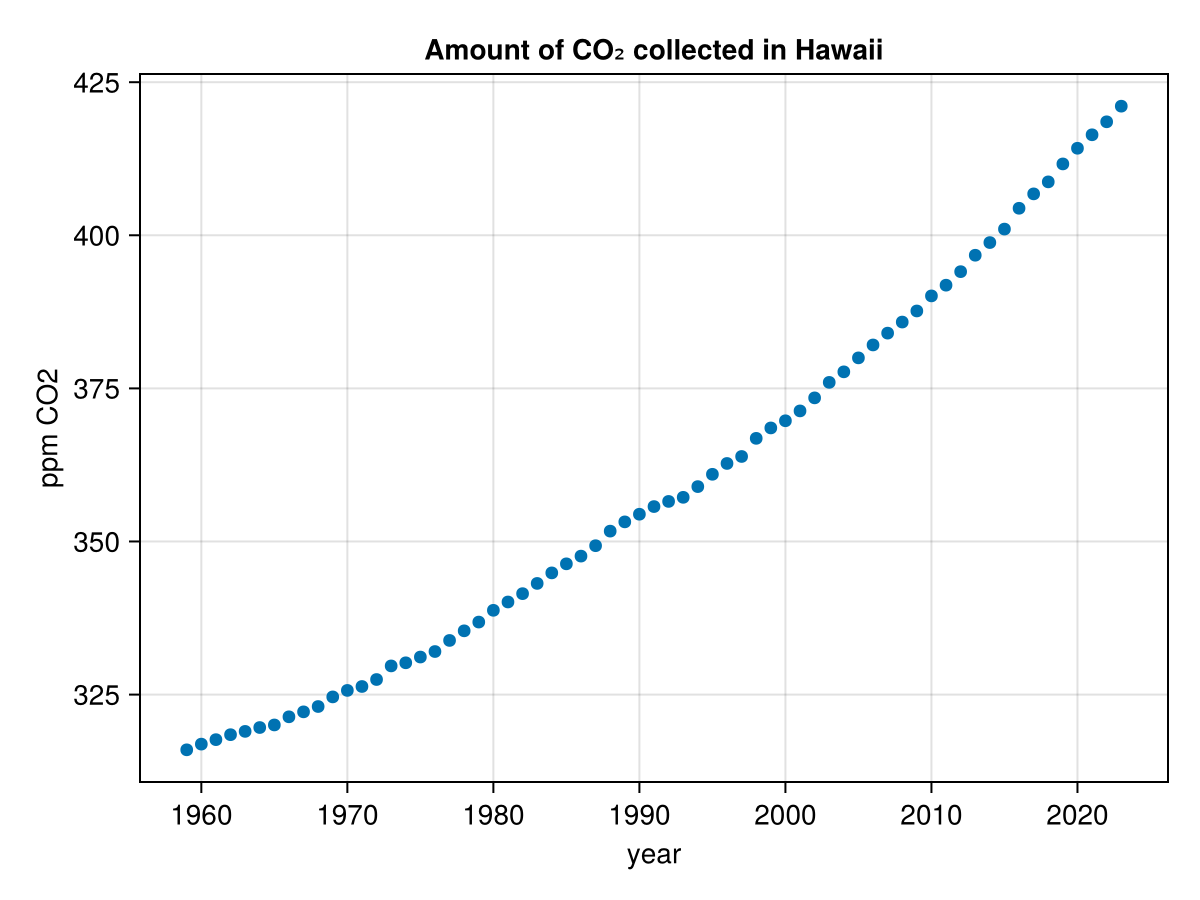

In [14]:
co2 = CSV.read("../data/co2_annmean_mlo.csv", DataFrame, header = 44, skipto = 45)
fig = Figure()
ax = Axis(fig[1,1], title = "Amount of CO₂ collected in Hawaii", 
xlabel = "year", ylabel = "ppm CO2")
scatter!(ax, co2.year, co2.mean)
fig

In [15]:
save("$output_dir/co2-scatter.png")

#29 (generic function with 1 method)

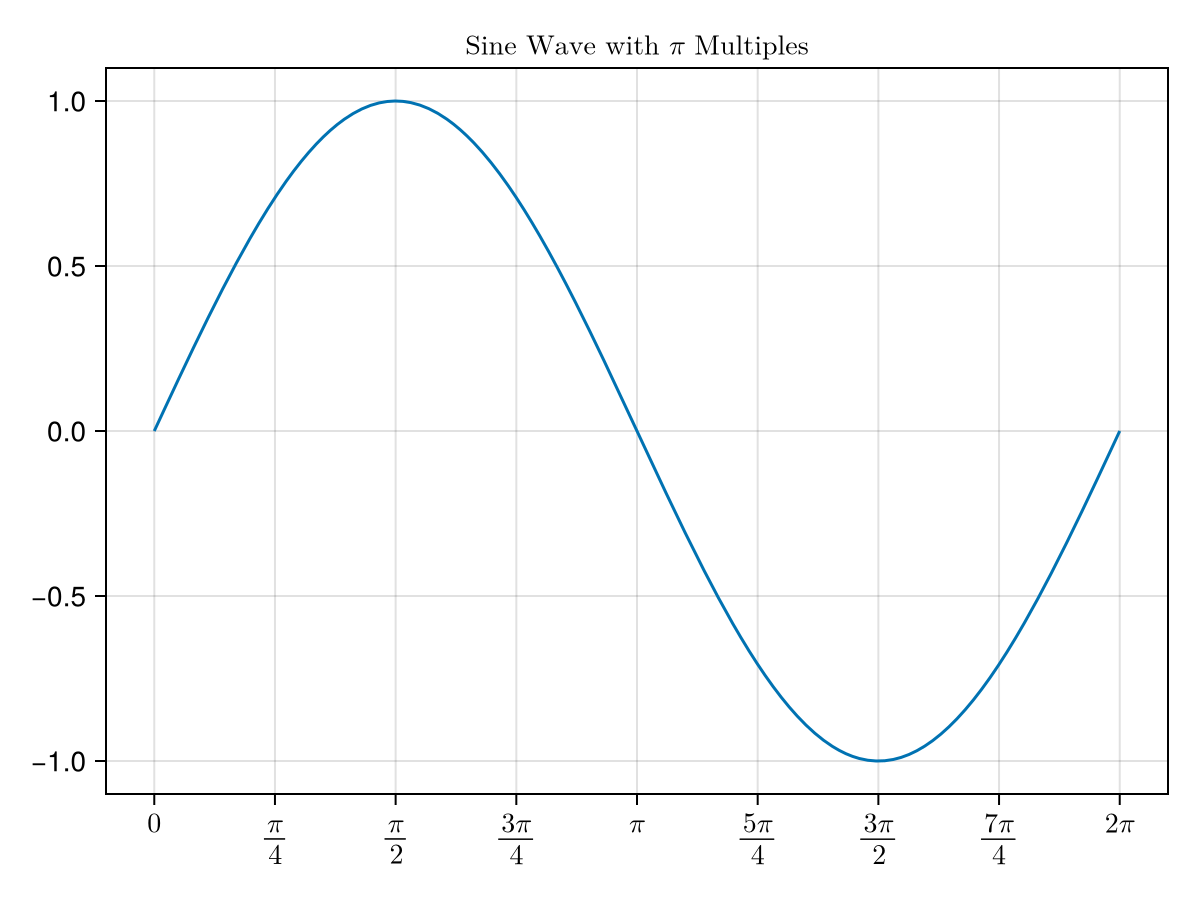

In [16]:
tick_pos = 0:pi/4:2pi
xlabels = [L"0", L"\frac{\pi}{4}", L"\frac{\pi}{2}", L"\frac{3\pi}{4}",
  L"\pi", L"\frac{5\pi}{4}", L"\frac{3\pi}{2}", L"\frac{7\pi}{4}", L"2\pi"]

fig = Figure()
ax = Axis(fig[1, 1],
  xticks=(tick_pos, xlabels),
  title=L"Sine Wave with $\pi$ Multiples"
)

lines!(ax, 0 .. 2pi, sin)
fig

In [17]:
save("$output_dir/sine-with-xticks.png", fig)

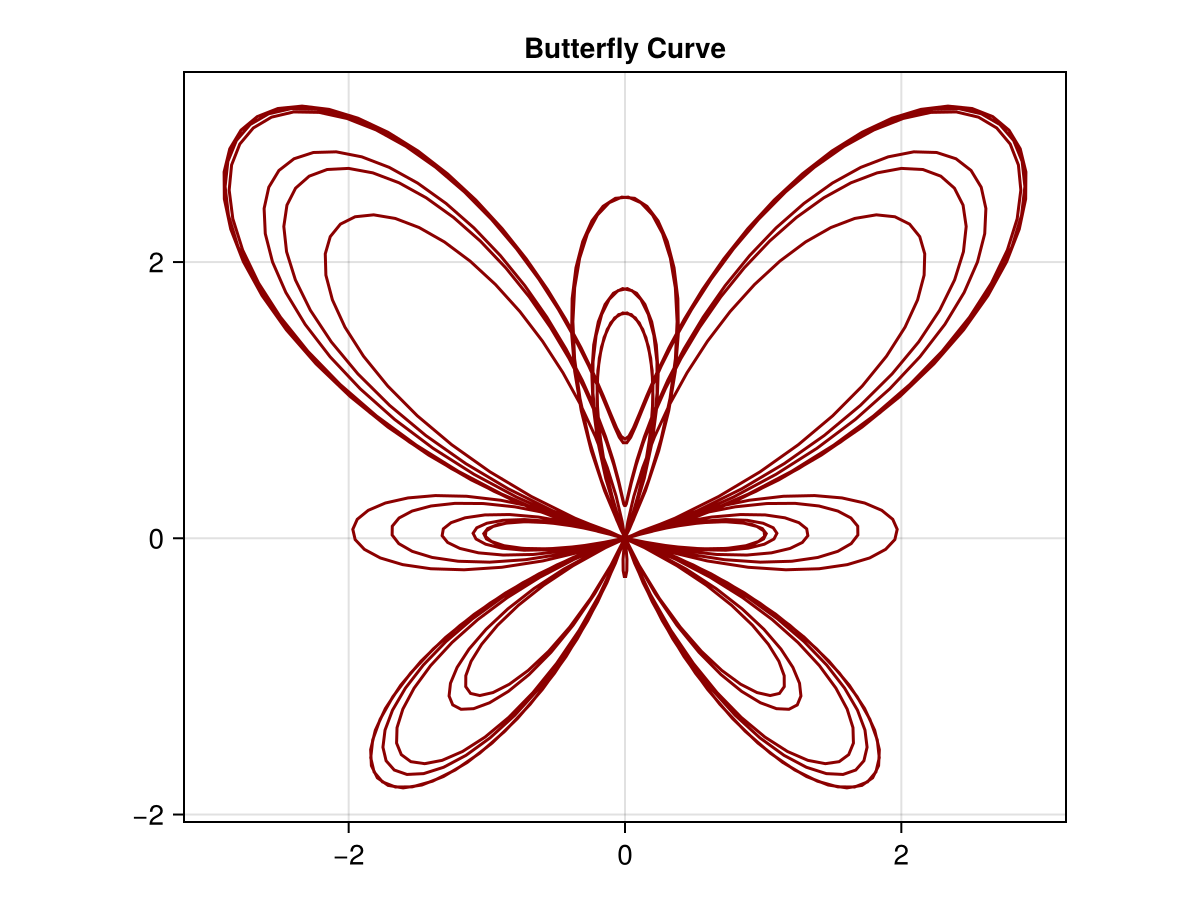

In [23]:
butterfly(t) = Point2f(
  sin(t) * (exp(cos(t)) - 2cos(4t) - sin(t / 12)^5),
  cos(t) * (exp(cos(t)) - 2cos(4t) - sin(t / 12)^5)
)

t_vals = range(0, 12π, length=1000)
points = butterfly.(t_vals)

fig = Figure()
ax = Axis(fig[1, 1], title="Butterfly Curve", aspect=DataAspect())

lines!(ax, points, color=:darkred)
fig

In [24]:
save("$output_dir/butterfly.png", fig)

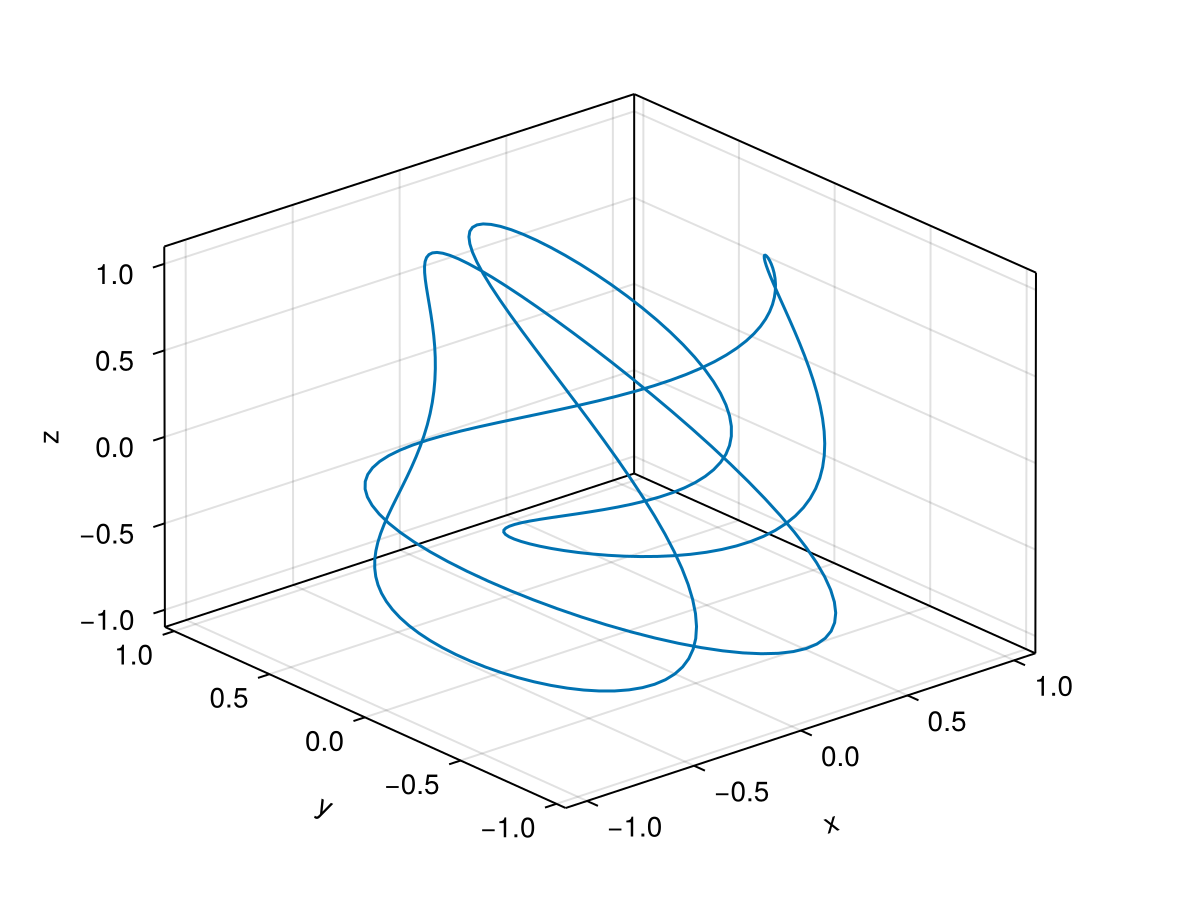

In [29]:
t = LinRange(0, 2 * pi, 300)
f(t) = Point3f(cos(2t) * cos(t), cos(5t) * sin(t), sin(3t))
fig = Figure()
ax = Axis3(fig[1, 1])
lines!(ax, f.(t))
fig

In [26]:
save("$output_dir/parametric3d.png", fig)

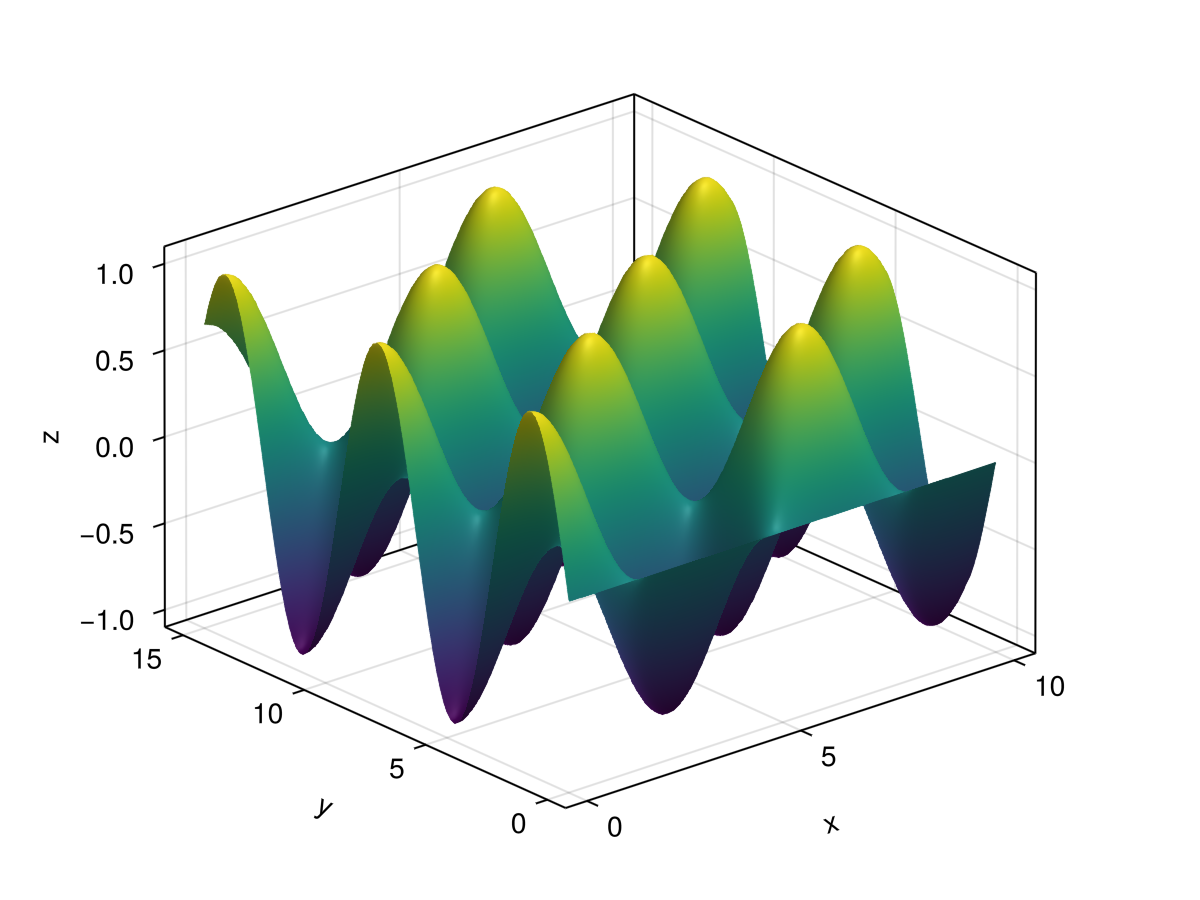

In [34]:
using GLMakie
GLMakie.activate!()
xs = LinRange(0, 10, 100)
ys = LinRange(0, 15, 100)
zs = [cos(x) * sin(y) for x in xs, y in ys]

fig = surface(xs, ys, zs, axis=(type=Axis3,))

In [35]:
save("$output_dir/surface.png", fig)

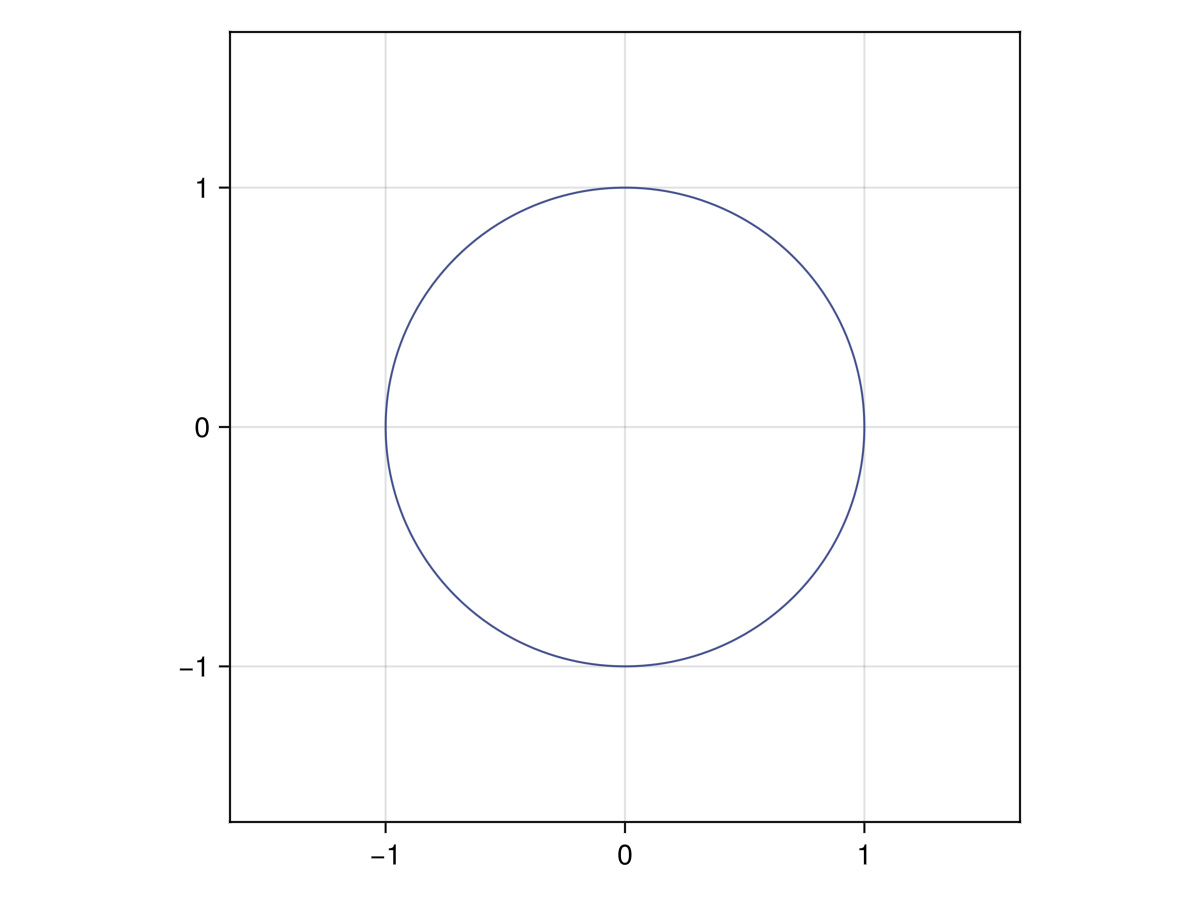

In [37]:
fig = Figure()
ax = Axis(fig[1, 1], aspect = 1)

x = y =  LinRange(-1.5, 1.5, 100)
contour!(ax, x,y,(x,y) -> x^2+y^2-1, levels=[0])
fig

In [38]:
save("$output_dir/implicit-circle.png", fig)

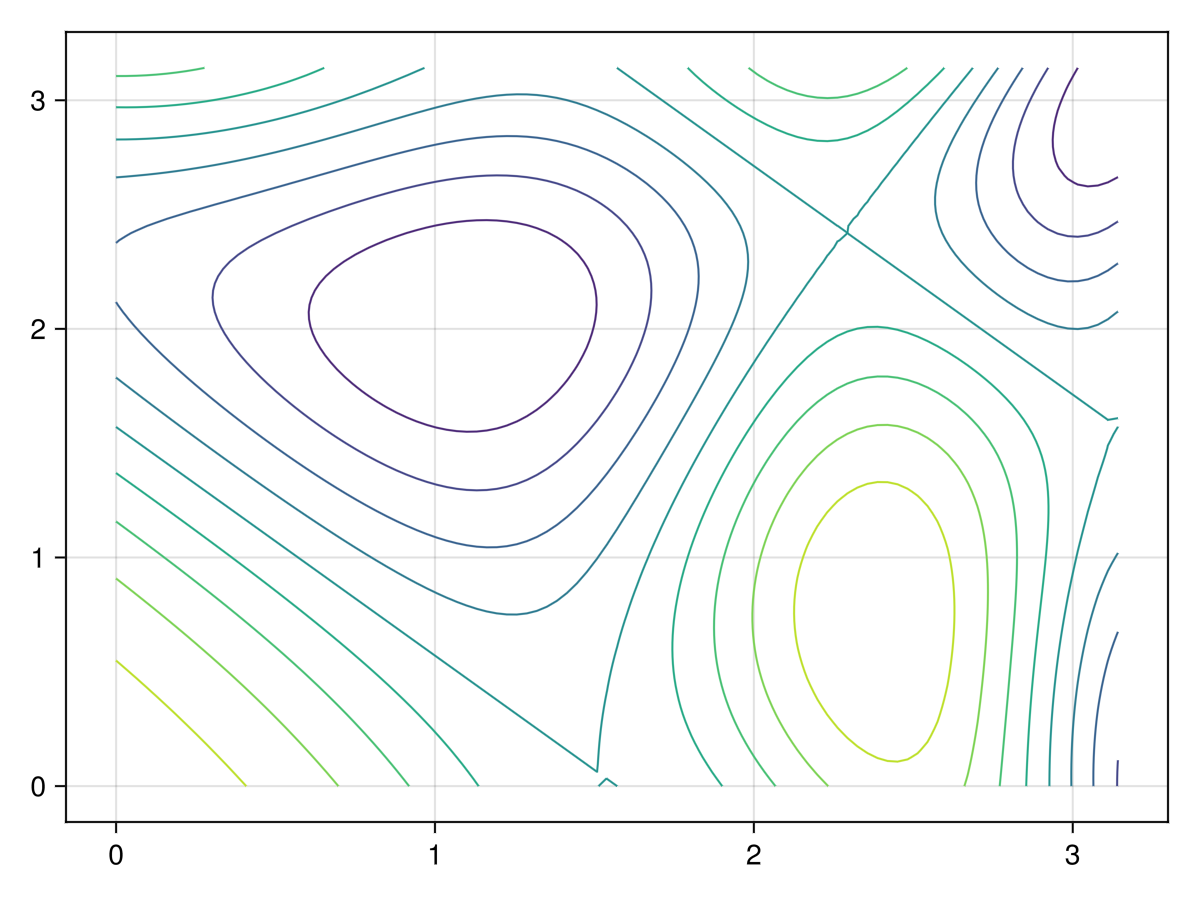

In [39]:
x = y = LinRange(0,pi,101)
fig = contour(x, y, (x, y) -> sin(0.5x^2-0.25y^2+2)*cos(x+y), levels = 9)

In [ ]:
save("$output_dir/contour.png", fig)


[54925] signal 15: Terminated: 15
in expression starting at none:1
poll at /usr/lib/system/libsystem_kernel.dylib (unknown line)
unknown function (ip: 0x0) at (unknown file)
__psynch_cvwait at /usr/lib/system/libsystem_kernel.dylib (unknown line)
unknown function (ip: 0x0) at (unknown file)
kevent at /usr/lib/system/libsystem_kernel.dylib (unknown line)
unknown function (ip: 0x0) at (unknown file)
Allocations: 217376703 (Pool: 217373757; Big: 2946); GC: 81


: 